In [1]:
import scipy.sparse as sp
import numpy as np
import matplotlib.pyplot as plt
from ldpc import BpOsdDecoder
from ldpc.mod2 import rank
from ldpc.codes import rep_code
#from ldpc.bpa import hgp

sqrt_pi = np.sqrt(np.pi)

In [2]:
def construct_hgp_stabilizers(H1, H2):
    """
    Build hypergraph stabilisers hz and hz 
    same pattern as when did ages ago
    """
    H1 = sp.csc_matrix(H1)
    H2 = sp.csc_matrix(H2)
    
    r1, n1 = H1.shape
    r2, n2 = H2.shape
    
    I_n1 = sp.eye(n1, format='csc')
    I_n2 = sp.eye(n2, format='csc')
    I_r1 = sp.eye(r1, format='csc')
    I_r2 = sp.eye(r2, format='csc')
    
    # HX = [ H1 tensor  I_n2 ,  I_r1 tensor H2.T ]
    HX_left = sp.kron(H1, I_n2, format='csc')
    HX_right = sp.kron(I_r1, H2.T, format='csc')
    Hx = sp.hstack([HX_left, HX_right], format='csc')
    
    # HZ = [ I_n1 tensor H2 ,  H1.T tensor I_r2 ]
    HZ_left = sp.kron(I_n1, H2, format='csc')
    HZ_right = sp.kron(H1.T, I_r2, format='csc')
    Hz = sp.hstack([HZ_left, HZ_right], format='csc')
    
    return Hx, Hz

In [3]:
def gkp_error_and_probability(sigma, n, cutoff=5):
    """error and probability returned"""
    displacement = np.random.normal(0, sigma, n)

    residual = (
        (displacement + sqrt_pi / 2) % sqrt_pi
    ) - sqrt_pi / 2

    error = (
        np.rint((displacement - residual) / sqrt_pi).astype(np.uint8) % 2
    )
    #gaussian prob
    k = np.arange(-cutoff, cutoff + 1)
    likelihood = np.exp(
        -(residual[:, None] + k[None, :] * sqrt_pi) ** 2
        / (2 * sigma**2)
    )

    odd = (np.abs(k) % 2) == 1
    p_error = likelihood[:, odd].sum(axis=1) / likelihood.sum(axis=1)
    #for bp
    p_error = np.clip(p_error, 1e-12, 1 - 1e-12)

    return error, p_error

In [4]:
def is_logical_z_error(residual, Hz, rank_Hz):
    if not np.any(residual):
        return False

    extended = sp.vstack([
        Hz,
        sp.csr_matrix(residual.reshape(1, -1))
    ])

    return rank(extended) > rank_Hz

In [5]:
import os
import json
import time

def gkp_qldpc_z_only(
    Hx,
    Hz,
    sigma_vals,
    max_trials=50_000,
    min_errors=100,
    min_trials=1_000,
    save_filename="gkp_qldpc_checkpoint.json",
):
    Hx = sp.csr_matrix(Hx, dtype=np.uint8)
    Hz = sp.csr_matrix(Hz, dtype=np.uint8)

    # Check that the CSS stabilizers commute.
    commutator = Hx @ Hz.T
    commutator.data %= 2
    commutator.eliminate_zeros()

    assert commutator.nnz == 0, "Hx and Hz do not commute"

    n = Hx.shape[1]
    rank_Hz = rank(Hz)

    decoder = BpOsdDecoder(
        Hx,
        error_rate=0.1,
        bp_method="product_sum",
        max_iter=n,
        schedule="serial",
        osd_method="osd_cs",
        osd_order=2,
    )

    code_key = f"hgp_n{n}"

    # Load an existing checkpoint if one exists.
    if os.path.exists(save_filename):
        with open(save_filename, "r") as file:
            saved_data = json.load(file)

        print(f"Loaded checkpoint from {save_filename}")
    else:
        saved_data = {}

    if code_key not in saved_data:
        saved_data[code_key] = {
            "sigma": [],
            "rate": [],
            "error_bar": [],
            "total_trials": [],
            "total_errors": [],
        }

    code_data = saved_data[code_key]
    last_save_time = time.time()

    for sigma in sigma_vals:
        sigma_rounded = round(float(sigma), 5)

        # Resume previously saved simulations.
        if sigma_rounded in code_data["sigma"]:
            index = code_data["sigma"].index(sigma_rounded)

            logical_errors = code_data["total_errors"][index]
            trials_run = code_data["total_trials"][index]

            finished = (
                trials_run >= max_trials
                or (
                    logical_errors >= min_errors
                    and trials_run >= min_trials
                )
            )

            if finished:
                print(
                    f"sigma={sigma_rounded} already finished: "
                    f"{trials_run} trials, "
                    f"{logical_errors} errors"
                )
                continue
            else:
                print(
                    f"Resuming sigma={sigma_rounded} from "
                    f"{trials_run} trials..."
                )

        # Start a new simulation.
        else:
            logical_errors = 0
            trials_run = 0

            print(f"Starting sigma={sigma_rounded}...")

        while trials_run < max_trials:
            batch_size = min(500, max_trials - trials_run)

            for _ in range(batch_size):
                z_error, p_z = gkp_error_and_probability(sigma, n)

                syndrome = np.asarray(
                    Hx @ z_error
                ).ravel() % 2

                decoder.update_channel_probs(p_z)

                correction = decoder.decode(
                    syndrome.astype(np.uint8)
                ).astype(np.uint8)

                assert np.array_equal(
                    np.asarray(Hx @ correction).ravel() % 2,
                    syndrome,
                )

                residual = (z_error + correction) % 2

                if is_logical_z_error(
                    residual,
                    Hz,
                    rank_Hz,
                ):
                    logical_errors += 1

            trials_run += batch_size

            # Stop after reaching both minimum conditions.
            if (
                logical_errors >= min_errors
                and trials_run >= min_trials
            ):
                break

        rate = logical_errors / trials_run
        error_bar = (
            np.sqrt(rate * (1.0 - rate) / trials_run)
            if trials_run > 0 else 0
        )

        if sigma_rounded in code_data["sigma"]:
            index = code_data["sigma"].index(sigma_rounded)
            code_data["rate"][index] = float(rate)
            code_data["error_bar"][index] = float(error_bar)
            code_data["total_trials"][index] = int(trials_run)
            code_data["total_errors"][index] = int(logical_errors)
        else:
            code_data["sigma"].append(sigma_rounded)
            code_data["rate"].append(float(rate))
            code_data["error_bar"].append(float(error_bar))
            code_data["total_trials"].append(int(trials_run))
            code_data["total_errors"].append(int(logical_errors))

        current_time = time.time()
        if current_time - last_save_time > 300 or sigma == sigma_vals[-1]:
            with open(save_filename, "w") as file:
                json.dump(saved_data, file, indent=4)
            print(
                f"--> Saved progress checkpoint to {save_filename} "
                f"(Total Trials: {trials_run}, Total Errors: {logical_errors})"
            )
            last_save_time = current_time

    sorted_indices = np.argsort(code_data["sigma"])

    rates_sigma = np.asarray([
        code_data["sigma"][i]
        for i in sorted_indices
    ])

    rates = np.asarray([
        code_data["rate"][i]
        for i in sorted_indices
    ])

    errors = np.asarray([
        code_data["error_bar"][i]
        for i in sorted_indices
    ])

    return rates_sigma, rates, errors

In [ ]:
H_hamming = sp.csr_matrix([
    [1, 0, 1, 0, 1, 0, 1],
    [0, 1, 1, 0, 0, 1, 1],
    [0, 0, 0, 1, 1, 1, 1],
], dtype=np.uint8)

H1 = H_hamming
H2 = H_hamming

Hx, Hz = construct_hgp_stabilizers(H1, H2)

sigma_vals = np.arange(0.30, 0.4, 0.025)

checkpoint_file = "gkp_qldpc_hamming_results_v2.json" 
plot_file = "GKP_qldpc_hamming_plot_v2.png"

rates_sigma, rates, errs = gkp_qldpc_z_only(
    Hx=Hx,
    Hz=Hz,
    sigma_vals=sigma_vals,
    max_trials=200000,
    min_errors=500,
    min_trials=20,
    save_filename=checkpoint_file,
)

plt.figure(figsize=(8, 6))

plt.errorbar(
    rates_sigma,
    rates,
    yerr=errs,
    fmt="o-",
    capsize=3,
    label="Hamming HGP [[58,16,3]]",
)

plt.yscale("log")
plt.xlabel(r"Sigma ($\sigma$)")
plt.ylabel("Logical Z error rate")
plt.title("GKP Hamming Hypergraph-Product Code")
plt.grid(True, which="both", linestyle="--")
plt.legend()
plt.tight_layout()

plt.savefig(
    plot_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Results saved to {checkpoint_file}")
print(f"Plot saved to {plot_file}")

Loaded checkpoint from gkp_qldpc_hamming_results.json
Resuming sigma=0.3 from 16000 trials...


KeyboardInterrupt: 

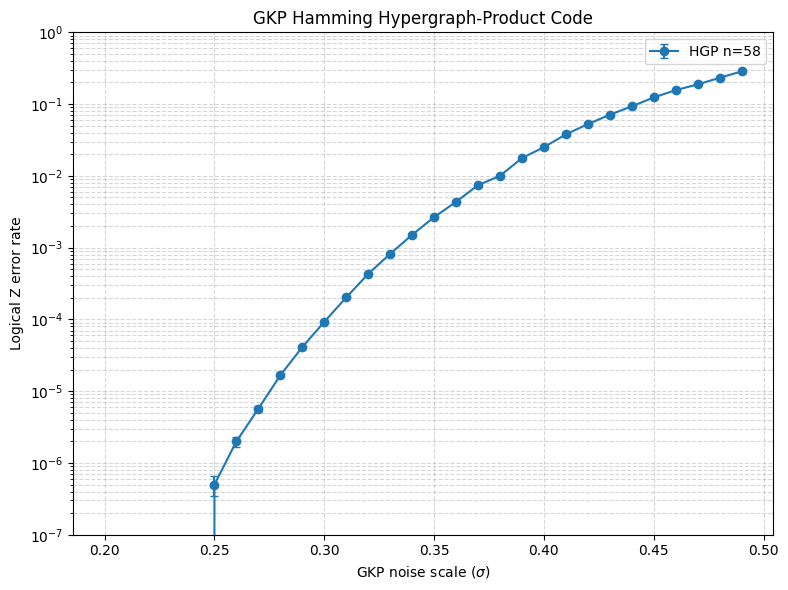

In [8]:
import json
import matplotlib.pyplot as plt

file_path = "gkp_qldpc_hamming_results_v2.json"

with open(file_path, "r") as f:
    data = json.load(f)

plt.figure(figsize=(8, 6))

for code_name, results in data.items():
    points = sorted(
        zip(
            results["sigma"],
            results["rate"],
            results["error_bar"],
        )
    )

    sigmas, rates, errors = map(list, zip(*points))

    plt.errorbar(
        sigmas,
        rates,
        yerr=errors,
        fmt="o-",
        capsize=3,
        label=code_name.replace("hgp_n", "HGP n="),
    )

plt.xlabel(r"GKP noise scale ($\sigma$)")
plt.ylabel("Logical Z error rate")
plt.title("GKP Hamming Hypergraph-Product Code")
plt.yscale("log")
plt.ylim(1e-7, 1)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()